In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score

In [2]:
# Load dataset
df = pd.read_csv("IMDB_Movies_Data.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
        id                                    title release_date  \
0  1127164                  Beetlejuice Beetlejuice   2024-09-04   
1   493529  Dungeons & Dragons: Honor Among Thieves   2023-03-23   
2   177677       Mission: Impossible - Rogue Nation   2015-07-28   
3  1064028                             Subservience   2024-08-15   
4  1405338                               Demon City   2025-02-26   

                            genres     budget    revenue  runtime  \
0            Comedy,Fantasy,Horror  100000000  451900435      105   
1         Adventure,Fantasy,Comedy  151000000  208200000      134   
2                 Action,Adventure  150000000  682716636      131   
3  Science Fiction,Horror,Thriller    4400000     262793      105   
4    Action,Crime,Fantasy,Thriller          0          0      106   

   vote_average  vote_count  popularity original_language  \
0         6.999        2681     10.3224                en   
1         7.300        4097      9.2202 

In [4]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values safely
if 'Revenue (Millions)' in df.columns:
    df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].mean())

if 'Metascore' in df.columns:
    df['Metascore'] = df['Metascore'].fillna(df['Metascore'].mean())


Missing Values:
id                      0
title                   0
release_date            0
genres                  0
budget                  0
revenue                 0
runtime                 0
vote_average            0
vote_count              0
popularity              0
original_language       0
production_countries    0
production_companies    0
cast                    0
director                0
overview                0
dtype: int64


In [9]:
# Clean column names first
df.columns = df.columns.str.strip()
# Drop columns safely
df = df.drop(columns=['Rank', 'Title', 'Description'], errors='ignore')

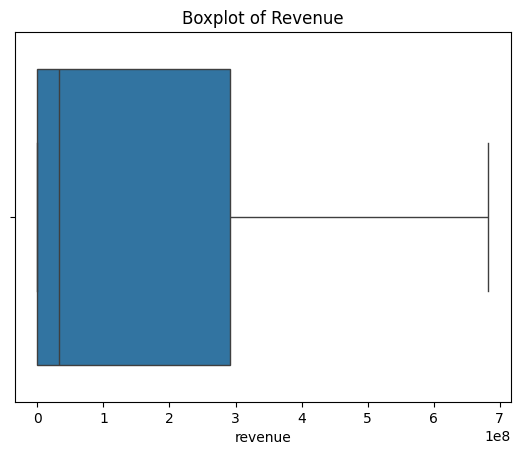

In [18]:
plt.figure()
sns.boxplot(x=df['revenue'])
plt.title("Boxplot of Revenue")
plt.show()

In [17]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['revenue'] >= Q1 - 1.5 * IQR) &
        (df['revenue'] <= Q3 + 1.5 * IQR)]

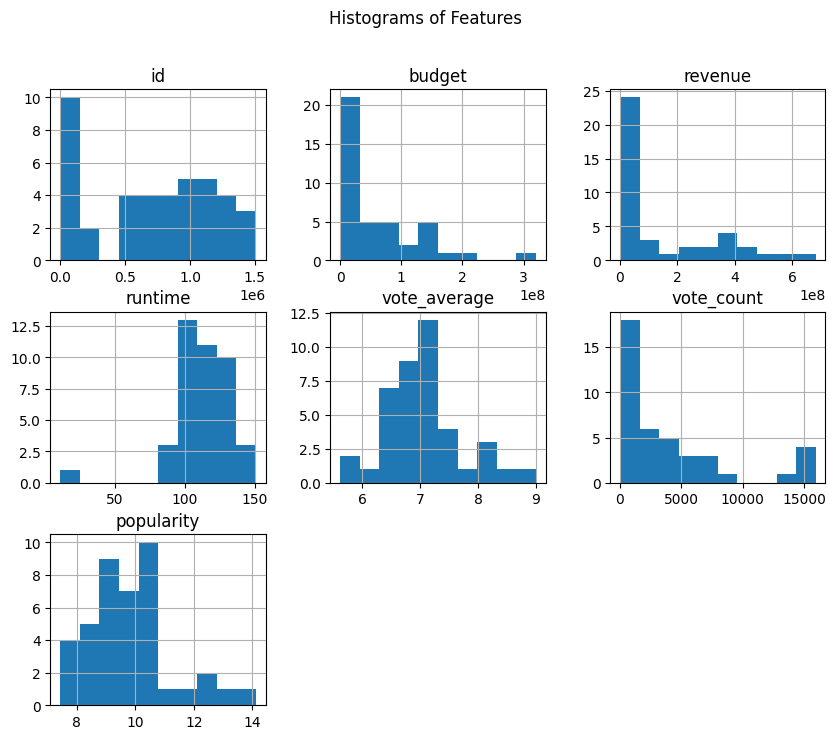

In [19]:
df.hist(figsize=(10,8))
plt.suptitle("Histograms of Features")
plt.show()

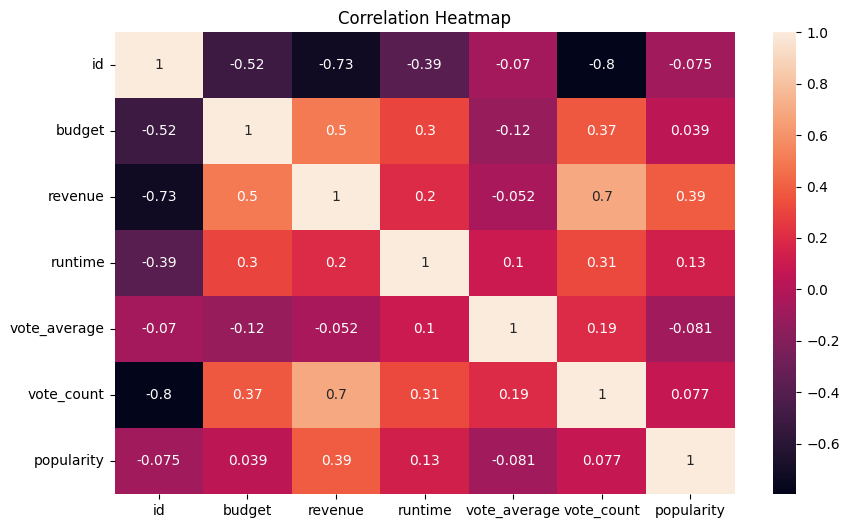

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [26]:
# Features and target
X = df.drop('runtime', axis=1)
y = df['runtime']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
# Predict on test data
y_pred = model.predict(X_test)
print("Predictions:")
print(y_pred[:5])

Predictions:
[121.43357909 103.67994834 110.94532834 116.83357258 126.56101702]


In [29]:
# Take one sample from test set
sample = X_test.iloc[0:1]

prediction = model.predict(sample)
print("Custom Prediction (runtime):", prediction)

Custom Prediction (runtime): [121.43357909]


In [30]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Mean Squared Error (MSE): 237.45738946192841
R2 Score: -0.2775005676418838


In [38]:
y_pred_class = y_pred.round()
y_test_class = y_test.round()

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_class, y_pred_class)

print("Accuracy:", accuracy)

Accuracy: 0.0
